In [1]:
import pandas as pd

# 1. Load the raw data
train_data = pd.read_csv('train.csv')

# 2. Re-apply our established /audit fixes (Imputation)
train_data['product_weight_kg'] = train_data['product_weight_kg'].fillna(train_data['product_weight_kg'].mean())
train_data['store_size'] = train_data['store_size'].fillna(train_data['store_size'].mode()[0])

# 3. FEATURE ENGINEERING: Price Tiers (Binning)
# pd.qcut divides the numerical prices into 4 mathematically equal distribution buckets
train_data['price_tier'] = pd.qcut(train_data['product_price'], q=4, labels=['Low', 'Medium', 'High', 'Premium'])

# 4. FEATURE ENGINEERING: Text to Numbers (One-Hot Encoding)
# pd.get_dummies converts categorical text columns into True/False (1/0) binary columns
columns_to_encode = ['store_format', 'store_location_tier', 'store_size', 'fat_content', 'price_tier', 'product_category']
train_engineered = pd.get_dummies(train_data, columns=columns_to_encode, drop_first=True)

# 5. Output the results
print("--- New Dataset Shape (Rows, Columns) ---")
print(train_engineered.shape)

print("\n--- Newly Engineered Columns ---")
# Filtering to just show a few of our new binary columns to keep the terminal clean
new_cols = [col for col in train_engineered.columns if 'store_format' in col or 'price_tier' in col]
print(new_cols)

# 6. Save the final pipeline output
train_engineered.to_csv('train_ready.csv', index=False)
print("\n--- Success: Model-ready data saved to 'train_ready.csv' ---")

--- New Dataset Shape (Rows, Columns) ---
(6818, 66)

--- Newly Engineered Columns ---
['store_format_Flagship Hypermarket', 'store_format_Standard Supermarket', 'store_format_Superstore', 'price_tier_Medium', 'price_tier_High', 'price_tier_Premium']

--- Success: Model-ready data saved to 'train_ready.csv' ---


--- Success: Chart saved as 'price_vs_sales.png' ---


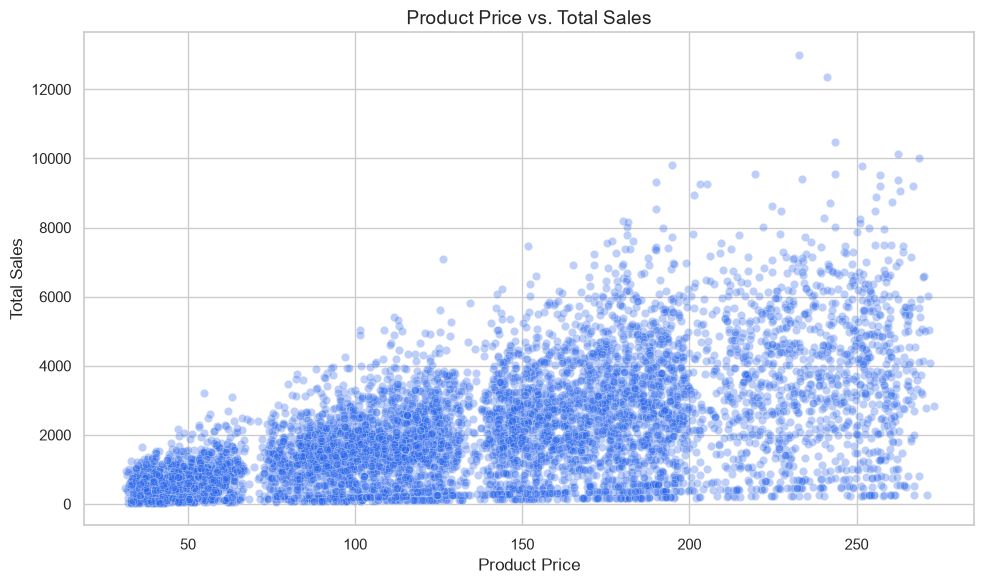

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load and clean the data
train_data = pd.read_csv('train.csv')
train_data['product_weight_kg'] = train_data['product_weight_kg'].fillna(train_data['product_weight_kg'].mean())
train_data['store_size'] = train_data['store_size'].fillna(train_data['store_size'].mode()[0])

# 2. Configure styling
sns.set_theme(style="whitegrid")

# 3. Create a scatter plot: Product Price vs. Total Sales
plt.figure(figsize=(10, 6))
# We use alpha=0.3 to make the dots slightly transparent, which helps us see where data clumps together
sns.scatterplot(x='product_price', y='total_sales', data=train_data, alpha=0.3, color='#2563eb')

# 4. Add labels and formatting
plt.title('Product Price vs. Total Sales', fontsize=14)
plt.xlabel('Product Price', fontsize=12)
plt.ylabel('Total Sales', fontsize=12)
plt.tight_layout()

# 5. Save the chart
plt.savefig('price_vs_sales.png')
print("--- Success: Chart saved as 'price_vs_sales.png' ---")

In [3]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor

# 1. Load the training data
df_train = pd.read_csv('train_ready.csv')
X_train = df_train.drop(columns=['total_sales', 'id', 'product_code', 'store_code'])
y_train = df_train['total_sales']

# 2. Train the Final Model on 100% of the Data
# We no longer need to hold back 20% for a mock exam. We want the model as smart as possible.
print("--- Training Final Engine on 100% of Historical Data... ---")
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 3. Load and Preprocess the Test Data
print("--- Processing Test Data... ---")
test_data = pd.read_csv('test.csv')

# We isolate the 'id' column because Kaggle requires it for the final upload
submission_ids = test_data['id']

# Apply Imputation (Patching holes)
test_data['product_weight_kg'] = test_data['product_weight_kg'].fillna(test_data['product_weight_kg'].mean())
test_data['store_size'] = test_data['store_size'].fillna(test_data['store_size'].mode()[0])

# Apply Feature Engineering (Price Tiers & One-Hot Encoding)
test_data['price_tier'] = pd.qcut(test_data['product_price'], q=4, labels=['Low', 'Medium', 'High', 'Premium'])
columns_to_encode = ['store_format', 'store_location_tier', 'store_size', 'fat_content', 'price_tier', 'product_category']
X_test = pd.get_dummies(test_data, columns=columns_to_encode, drop_first=True)

# 4. ARCHITECT GUARDRAIL: Align Schemas
# This forces the test columns to perfectly match the training columns. 
# If the test set lacks a specific category, this fills the missing column with 0 (False) to prevent crashes.
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

# 5. Generate Final Predictions
print("--- Generating Predictions... ---")
predictions = model.predict(X_test)

# 6. Format for Kaggle Submission
submission = pd.DataFrame({
    'id': submission_ids,
    'total_sales': predictions
})

submission.to_csv('final_submission.csv', index=False)
print("--- Success: 'final_submission.csv' generated and ready for Kaggle! ---")

--- Training Final Engine on 100% of Historical Data... ---
--- Processing Test Data... ---
--- Generating Predictions... ---
--- Success: 'final_submission.csv' generated and ready for Kaggle! ---
